# 04 — Compute ACE Descriptors

Computes Atomic Cluster Expansion (ACE) descriptors for all training structures.

## Prerequisites / Input files
- `Fe-Mo/Atomsobjects/Fe-Mo-POSCAR-initial-rescaled-AtomsObjects.pkl`
- `python-ace` package (public, included in `environment_public.yaml`)

## Outputs
- `Fe-Mo/Descriptors/Fe-Mo-*-ACE-CNAV.csv`

## Notes
> ⚠️ ACE descriptor computation may require a separate Python environment. Test with `conda activate datasets_ml` before running.



#  Calculation of features from available libraries

In [1]:
from Tools.DatasetTools.Commoms import *
from ase import Atoms

In [2]:
plt.rc('text', usetex=False)
plt.rc('font', family='serif', size=24)

In [3]:
dataset = 'Fe-Mo'# 'Fe-Mo'  # 'Cr-Co-W' # 
components = dataset.split('-')
system=dataset.replace('-','')
from  dependencies.bopfoxfeaturizer.BopFoxFeaturizer.Featurizer import Featurizer

import Tools.DatasetTools.GeneralFeaturizer as gf


In [4]:
from importlib.machinery import SourceFileLoader
from sklearn.preprocessing import  OneHotEncoder, LabelEncoder
encoder = LabelEncoder()
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.Featurizer import Featurizer

In [5]:
from Tools.DatasetTools.GeneralFeaturizer import cn_persite

In [6]:

BS = pd.read_json(os.path.join(dataset, 'FullyCuratedParsedBriefSummary.json'))

In [7]:
BS.describe()

,E0,encut,deltak,ncrash,nelem,B0,V0,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc
count,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000
mean,-9.338579,448.287671,0.019801,0.003425,1.845890,234.670348,13.567736,12.756849,10.291096,23.047945,0.502059,0.497941,0.249920,0.228510,0.204721
std,0.746072,10.211481,0.000882,0.058521,0.361674,32.626162,1.649340,10.598861,9.537817,13.658995,0.292601,0.292601,0.162025,0.162157,0.166286
min,-10.932821,400.000000,0.012000,0.000000,1.000000,102.152576,10.193528,1.000000,0.000000,1.000000,0.000000,0.000000,-0.015446,-0.042841,-0.085488
25%,-9.954712,450.000000,0.020000,0.000000,2.000000,217.589748,12.251636,4.000000,2.750000,13.000000,0.266667,0.266667,0.124923,0.102939,0.072821
50%,-9.328441,450.000000,0.020000,0.000000,2.000000,240.028922,13.368936,10.000000,8.500000,24.000000,0.500000,0.500000,0.227416,0.192728,0.172018
75%,-8.810896,450.000000,0.020000,0.000000,2.000000,260.406947,14.934529,18.000000,16.000000,30.000000,0.733333,0.733333,0.364194,0.336165,0.309251
max,-7.780036,500.000000,0.021000,1.000000,2.000000,287.828951,16.550514,53.000000,52.000000,53.000000,1.000000,1.000000,0.720532,0.720492,0.720492


In [8]:
AtomsObjects = pd.read_json(os.path.join(dataset, 'Atomsobjects', f'{dataset}-POSCAR.initial-rescaled-AtomsObjects.json')).dropna()
AtomsObjects['atoms'] = AtomsObjects['atoms'].map(lambda a: Atoms.fromdict(a))

#Pymatgen_Structures = AtomsObjects['atoms'].apply(AseAtomsAdaptor.get_structure)
#Pymatgen_Structures['file'] = AtomsObjects['file']


In [9]:

#PymatgenStructures = pd.read_pickle(os.path.join(dataset, 'Atomsobjects', f'{dataset}-POSCAR-initial-rescaled-PymatgenStructures.pkl')).dropna()
SublatticeTags = pd.read_pickle(os.path.join(dataset,'Atomsobjects', 'SUBLATICETAGS_POSCAR.initial.pkl'))
SublatticeSorters = pd.read_pickle(os.path.join(dataset,'Atomsobjects', 'SORTERS_POSCAR.initial.pkl'))
SublatticeSorters.index = SublatticeSorters.index.str.strip()
SublatticeTags.index = SublatticeSorters.index.str.strip()

BS.dropna(inplace=True)

import numpy as np

descriptorslocation = os.path.join(dataset, 'Descriptors')

# Prepare Extra features

In [10]:
Features = Featurizer(BS)

In [11]:
DatasetCompositionFeatures = Features.get_fractions_by_components()

##  Magnetism and structure

In [12]:
StructureNameFeature = BS.Phase
StructureNameFeature.name='Structure'
encoder.fit(StructureNameFeature)
DatasetStructureFeature = pd.Series(encoder.transform(StructureNameFeature), name='Structure', index = StructureNameFeature.index)

In [13]:
MagneticFeature = Features.MagFeature
MagneticFeature.name = 'Mag'
encoder.fit(MagneticFeature)
DatasetMagneticFeature = pd.Series(encoder.transform(MagneticFeature), name='Mag', index = StructureNameFeature.index)

In [14]:
DatasetFeatures = pd.concat([DatasetMagneticFeature, DatasetStructureFeature, DatasetCompositionFeatures, BS.num_atoms], axis = 1)

## Coordination Polyhedra feature

The first feature that we would like to have is the count of each CP in each sample. for that we construct a vector in the following way:

$$ N_{CN}^i = \#^i CP $$

Next feature we want is the composition in each CP. for this we choose to represent the elment numerically by their atomic numbers, and the CP-resolved composition becomes the average atomc numbers,

$$ Z_{CP} ^i = \dfrac{1}{n_{at}^i} \sum_{at \in CP} Z_{at} $$

In [15]:
BS.index

Index(['Fe_pv4Mo_sv20.C36-ABBBB.FM', 'Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM',
       'Fe_pv2Mo_sv11.mu-BBABB.FM', 'Fe_pv8Mo_sv22.sigma-BBBAB.NM',
       'Fe_pv2Mo_sv11.mu-BBBBA.NM', 'Fe_pv4Mo_sv20.C36-BBABB.NM',
       'Fe_pv2Mo_sv10.C14-BAB.NM', 'Fe_pv9Mo_sv44.R-AAABBBBBBBB.NM',
       'Fe_pv4Mo_sv26.sigma-BABBB.NM', 'Fe_pv1Mo_sv12.mu-ABBBB.NM',
       ...
       'Fe_pv6Mo_sv2.A15-AB.NM', 'Fe_pv8Mo_sv16.C36-BAABB.NM',
       'Fe_pv30.sigma.FM', 'Fe_pv4.fcc-cubic.FM', 'Fe_pv6.C15.FM',
       'Mo_sv1.bcc.NM', 'Mo_sv8.A15.NM', 'Mo_sv1.fcc.NM', 'Mo_sv6.C15.NM',
       'Fe_pv12.C14.FM'],
      dtype='object', length=292)

In [16]:
AtomsObjects.index

Index(['Fe_pv4Mo_sv20.C36-ABBBB.FM', 'Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM',
       'Fe_pv2Mo_sv11.mu-BBABB.FM', 'Fe_pv8Mo_sv22.sigma-BBBAB.NM',
       'Fe_pv2Mo_sv11.mu-BBBBA.NM', 'Fe_pv4Mo_sv20.C36-BBABB.NM',
       'Fe_pv2Mo_sv10.C14-BAB.NM', 'Fe_pv9Mo_sv44.R-AAABBBBBBBB.NM',
       'Fe_pv4Mo_sv26.sigma-BABBB.NM', 'Fe_pv1Mo_sv12.mu-ABBBB.NM',
       ...
       'Fe_pv6Mo_sv2.A15-AB.NM', 'Fe_pv8Mo_sv16.C36-BAABB.NM',
       'Fe_pv30.sigma.FM', 'Fe_pv4.fcc-cubic.FM', 'Fe_pv6.C15.FM',
       'Mo_sv1.bcc.NM', 'Mo_sv8.A15.NM', 'Mo_sv1.fcc.NM', 'Mo_sv6.C15.NM',
       'Fe_pv12.C14.FM'],
      dtype='object', length=292)

In [17]:
intersection = AtomsObjects.index.intersection(BS.index)

In [18]:
AtomsObjects = AtomsObjects.loc[intersection]

In [19]:
BS = BS.loc[intersection]

In [20]:
SortingFeatures = gf.sorting_feature(AtomsObjects, SublatticeSorters, SublatticeTags)
SortingFeatures.sorters = gf.correct_sortings_fromphases(AtomsObjects, BS.Phase, SortingFeatures.sorters)
SortingFeatures.sublatticetags = gf.correct_occupation_fromphases(BS.Phase, SortingFeatures.sublatticetags, AtomsObjects.atoms)
sampleinspecial = BS.Phase.map(lambda p: p in gf.specialphases)
empty = SortingFeatures.sublatticetags.map(lambda sublat: '' in sublat)
SortingFeatures.sublatticetags[empty] = ['A']
wrong = SortingFeatures.sublatticetags.map(lambda sublat: 'A' not in sublat) 
fixable = SortingFeatures.sublatticetags.loc[wrong].map(type) == np.ndarray #.map(np.unique)

In [21]:
CNList = gf.get_sitecn(BS.Phase, AtomsObjects.atoms, SortingFeatures.sorters)

  0%|          | 0/292 [00:00<?, ?it/s]

In [22]:
SortingFeatures.sorters = SortingFeatures.sorters.loc[intersection]

## Position Features

In [23]:
elements = np.unique(BS.filter(regex='^atom_').values.ravel())
ABOCC = pd.concat([BS.filter(regex='atom_'), Features.occupation], axis = 1)
ABOCC.rename(columns={ABOCC.columns[-1]: 'sublatticetags'}, inplace=True)

In [24]:
ABOCC=ABOCC.loc[intersection]

In [25]:
Positions = {}
for index, item in ABOCC.iterrows():
    if item['sublatticetags'] == '':
        thisposition = {index: [item[f'atom_A']]*len(np.unique(gf.cn_dict[BS.Phase[index]]))}
    else:
        thisposition = {index: [item[f'atom_{occ}'] for occ in item['sublatticetags'] ]}
    Positions.update(thisposition)
    

In [26]:
Positions = pd.DataFrame.from_dict(Positions, orient='index')
Positions[Positions.isnull()] = 0
for i, element in enumerate(elements):
    Positions[Positions==element] = i
Positions.columns = [f'Pos_{col+1}' for col in Positions.columns]
#Positions[Positions.Pos_1.map(type) == str] = np.nan

## Averages over Coordination polyhedra

### Number of each CP in each structure

In [27]:
CN = gf.featurize_series(CNList, CNList, normalization='NCP', return0 = False)
newcolumns = ['N'+col for col in CN.columns]
CN.columns = newcolumns

### Composition and volume of the CP

In [28]:
from mendeleev import element

In [29]:
AtomicNumbers=AtomsObjects.atoms.map(lambda a: a.numbers)
AtomicNumbers.name = 'AtomicNumbers'
symbols = dataset.split('-')
volums = {symb: element(symb).atomic_volume for symb in symbols}

In [30]:
AtomicVolumes = AtomsObjects.atoms.map(lambda a: np.array([volums[at] for at in a.get_chemical_symbols()]))

In [31]:
CPVol = gf.featurize_series(AtomicVolumes, CNList, return0=False, normalization='NCP')
newcolumns = ['V'+col for col in CPVol.columns]
CPVol.columns =  newcolumns

In [32]:
CPComp = gf.featurize_series(AtomicNumbers, CNList, return0=False, normalization='NCP')
newcolumns = ['Z'+col for col in CPComp.columns]
CPComp.columns = newcolumns

## Compile all the descriptors

In [33]:
DatasetFeatures = pd.concat([DatasetStructureFeature, DatasetMagneticFeature, DatasetCompositionFeatures, CN, CPVol, CPComp, BS.num_atoms, Positions], axis=1)
datasetfeatureslocation = os.path.join(dataset, 'Descriptors','DatasetFeatures.pkl')
CNListlocation = os.path.join(dataset, 'Descriptors', 'CNList.pkl')
DatasetFeatures.to_pickle(datasetfeatureslocation)
CNList.to_pickle(CNListlocation)

In [34]:
BS['atoms_objects'] = AtomsObjects['atoms']

# ACE Features 

In [35]:
from ase.atoms import Atoms
from importlib.machinery import SourceFileLoader
from Tools.DatasetTools.ACEDescriptors import MyPyACECalculator 
from Tools.DatasetTools.ACEDescriptors import default_options_dict as default_options_dict
from pyace import ACEBBasisSet, PyACECalculator

In [36]:
def reset_symbols(a: Atoms, newsym : str = 'W'):
    newa = a.copy()
    natoms = newa.get_global_number_of_atoms()
    newsymbols = [newsym]*natoms
    newa.set_chemical_symbols(newsymbols)
    return newa

In [37]:
AceConfig = copy.copy(default_options_dict)

In [38]:
AceConfig['elements'] = dataset.split('-')

In [39]:
ACEer = MyPyACECalculator(components = components, multispace_basis_config = AceConfig)

In [40]:
ACEer.bbasis_configuration.total_number_of_functions

600

In [41]:
ACEFEATURES = AtomsObjects['atoms'].map(ACEer.get_ace_projections)
ACEFEATURES.name = 'ace_projections'

In [42]:
expand_ace = gf.array_expansions(ACEFEATURES.to_frame(),['ace_projections']) 

In [43]:
CNAV_ACE = gf.featurize_dataframe(expand_ace, CNList).astype(np.single)

  0%|          | 0/300 [00:00<?, ?it/s]

In [44]:
CNAV_ACE

,ace_projections_0_0,ace_projections_0_CN12,ace_projections_0_CN13,ace_projections_0_CN14,ace_projections_0_CN15,ace_projections_0_CN16,ace_projections_1_0,ace_projections_1_CN12,ace_projections_1_CN13,ace_projections_1_CN14,...,ace_projections_298_CN13,ace_projections_298_CN14,ace_projections_298_CN15,ace_projections_298_CN16,ace_projections_299_0,ace_projections_299_CN12,ace_projections_299_CN13,ace_projections_299_CN14,ace_projections_299_CN15,ace_projections_299_CN16
Fe_pv4Mo_sv20.C36-ABBBB.FM,0.700782,0.519960,0.0,0.000000,0.000000,0.180822,0.740542,0.492038,0.0,0.000000,...,0.0,0.000000,0.000000,31.343937,539.530212,315.380646,0.0,0.000000,0.000000,224.149597
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,1.227271,0.573550,0.0,0.277732,0.146631,0.229359,1.211142,0.612540,0.0,0.242047,...,0.0,26.184114,13.263720,14.413171,314.198639,187.356995,0.0,66.610390,31.580824,28.650434
Fe_pv2Mo_sv11.mu-BBABB.FM,0.619778,0.311880,0.0,0.155909,0.121008,0.030980,0.676809,0.351540,0.0,0.125074,...,0.0,14.082514,13.368032,9.052814,638.642456,354.833435,0.0,42.839725,55.100155,185.869141
Fe_pv8Mo_sv22.sigma-BBBAB.NM,1.153250,0.300465,0.0,0.685557,0.167228,0.000000,1.148779,0.398667,0.0,0.569691,...,0.0,58.701118,15.163990,0.000000,335.942291,159.659134,0.0,138.973785,37.309368,0.000000
Fe_pv2Mo_sv11.mu-BBBBA.NM,0.630194,0.345619,0.0,0.063364,0.155909,0.065302,0.663000,0.350802,0.0,0.098787,...,0.0,11.676299,12.885588,15.284929,602.716919,319.076141,0.0,104.451942,38.337761,140.851059
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Mo_sv1.bcc.NM,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.000000,0.000000,0.000000,1024.395142,0.000000,0.0,1024.395142,0.000000,0.000000
Mo_sv8.A15.NM,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.000000,0.000000,0.000000,1019.029419,255.017288,0.0,764.012085,0.000000,0.000000
Mo_sv1.fcc.NM,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.000000,0.000000,0.000000,1016.059265,1016.059265,0.0,0.000000,0.000000,0.000000
Mo_sv6.C15.NM,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.000000,0.000000,0.000000,1018.994019,681.238892,0.0,0.000000,0.000000,337.755096


In [45]:
selection = CNAV_ACE[Features.StrucNames.loc[intersection] == 'bcc'].filter(regex='_0$')

In [46]:
selection

,ace_projections_0_0,ace_projections_1_0,ace_projections_2_0,ace_projections_3_0,ace_projections_4_0,ace_projections_5_0,ace_projections_6_0,ace_projections_7_0,ace_projections_8_0,ace_projections_9_0,...,ace_projections_290_0,ace_projections_291_0,ace_projections_292_0,ace_projections_293_0,ace_projections_294_0,ace_projections_295_0,ace_projections_296_0,ace_projections_297_0,ace_projections_298_0,ace_projections_299_0
Fe_pv1.bcc.FM,5.561434,5.31806,2.78563,4.32088,1.476867,-2.705837,1.71095,5.201591,3.179378,5.275408,...,0.0,0.000000,0.000000e+00,0.0,5320.274414,0.0,0.0,0.0,0.0,0.000000
Fe_pv1.bcc.NM,5.561434,5.31806,2.78563,4.32088,1.476867,-2.705837,1.71095,5.201591,3.179378,5.275408,...,0.0,0.000000,0.000000e+00,0.0,5320.274414,0.0,0.0,0.0,0.0,0.000000
Mo_sv1.bcc.FM,0.000000,0.00000,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.0,256.079041,-1.680822e-31,0.0,0.000000,0.0,0.0,0.0,0.0,1024.395142
Fe_pv2.bcc-cubic.FM,5.561434,5.31806,2.78563,4.32088,1.476867,-2.705837,1.71095,5.201591,3.179378,5.275408,...,0.0,0.000000,0.000000e+00,0.0,5320.274414,0.0,0.0,0.0,0.0,0.000000
Mo_sv1.bcc.NM,0.000000,0.00000,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.0,256.079041,-1.680822e-31,0.0,0.000000,0.0,0.0,0.0,0.0,1024.395142


Text(0.5, 0, 'lexycographic ordering')

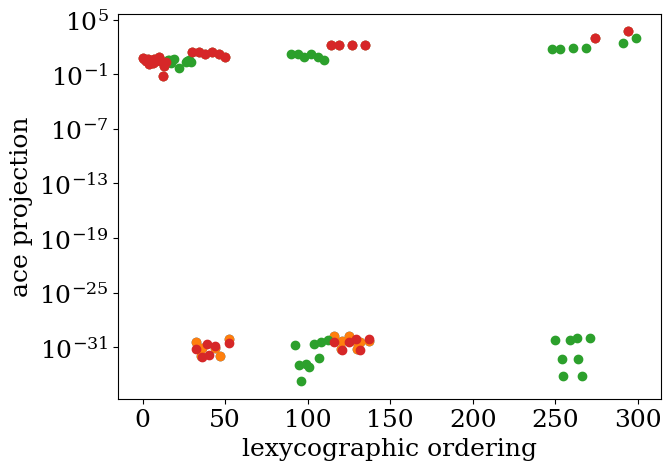

In [47]:
fig, ax = plt.subplots()
ax.plot(selection.iloc[0].values, 'o')
ax.plot(selection.iloc[1].values, 'o')
ax.plot(selection.iloc[2].values, 'o')
ax.plot(selection.iloc[3].values, 'o')
ax.set_yscale('log')
ax.set_ylabel('ace projection')
ax.set_xlabel('lexycographic ordering')

In [48]:
ACE_file = os.path.join(descriptorslocation, f'{dataset}-ACE-CNAV.csv')

CNAV_ACE.to_csv(ACE_file)

# Compare to DFT relaxed

In [49]:
AtomsObjectsRLX = pd.read_json(os.path.join(dataset, 'Atomsobjects', f'{dataset}-POSCAR.relaxed-all-noscaled-AtomsObjects.json')).dropna()
AtomsObjectsRLX['atoms'] = AtomsObjectsRLX['atoms'].map(Atoms.fromdict)


In [50]:
ACE_RLX = AtomsObjectsRLX['atoms'].map(ACEer.get_ace_projections)
ACE_RLX.name = 'ace_projections'

In [51]:
ACE_RLX

Fe_pv4Mo_sv20.C36-ABBBB.FM         [[0.308378561292857, 0.6766512788603869, 0.811...
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM    [[0.7026669310323557, 1.4102939203429525, 1.19...
Fe_pv2Mo_sv11.mu-BBABB.FM          [[0.7135863843949553, 0.6745697740861416, 0.17...
Fe_pv8Mo_sv22.sigma-BBBAB.NM       [[0.8606692163821301, 1.3548375898587073, 1.24...
Fe_pv2Mo_sv11.mu-BBBBA.NM          [[0.4967847829480212, 0.5302263603552979, 0.92...
                                                         ...                        
Mo_sv1.bcc.NM                      [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
Mo_sv8.A15.NM                      [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
Mo_sv1.fcc.NM                      [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
Mo_sv6.C15.NM                      [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
Fe_pv12.C14.FM                     [[5.445004888044523, 5.125218709271598, 2.9593...
Name: ace_projections, Length: 292, dtype: object

In [52]:
expand_ace_rlx = gf.array_expansions(ACE_RLX.to_frame(),['ace_projections']) 

In [53]:
CNAV_ACE_RLX = gf.featurize_dataframe(expand_ace_rlx.loc[intersection], CNList.loc[intersection]).astype(np.single)

  0%|          | 0/300 [00:00<?, ?it/s]

In [54]:
CNAV_ACE_RLX

,ace_projections_0_0,ace_projections_0_CN12,ace_projections_0_CN13,ace_projections_0_CN14,ace_projections_0_CN15,ace_projections_0_CN16,ace_projections_1_0,ace_projections_1_CN12,ace_projections_1_CN13,ace_projections_1_CN14,...,ace_projections_298_CN13,ace_projections_298_CN14,ace_projections_298_CN15,ace_projections_298_CN16,ace_projections_299_0,ace_projections_299_CN12,ace_projections_299_CN13,ace_projections_299_CN14,ace_projections_299_CN15,ace_projections_299_CN16
Fe_pv4Mo_sv20.C36-ABBBB.FM,0.664341,0.495581,0.0,0.000000,0.000000,0.168760,0.713721,0.481498,0.0,0.000000,...,0.0,0.000000,0.000000,23.335342,417.399719,239.959732,0.0,0.000000,0.000000,177.440002
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,1.275646,0.608327,0.0,0.273320,0.149192,0.244808,1.211287,0.611292,0.0,0.250945,...,0.0,27.860310,14.400973,16.914488,340.292236,200.083054,0.0,73.487572,34.251797,32.469799
Fe_pv2Mo_sv11.mu-BBABB.FM,0.626506,0.326654,0.0,0.153579,0.109783,0.036491,0.645850,0.320466,0.0,0.122136,...,0.0,13.429521,13.970778,7.365526,479.999420,256.056183,0.0,41.138512,65.757584,117.047150
Fe_pv8Mo_sv22.sigma-BBBAB.NM,1.186391,0.311062,0.0,0.703821,0.171508,0.000000,1.168615,0.411086,0.0,0.577756,...,0.0,68.318825,17.143711,0.000000,386.018707,181.345108,0.0,162.531708,42.141899,0.000000
Fe_pv2Mo_sv11.mu-BBBBA.NM,0.631638,0.338401,0.0,0.076428,0.165563,0.051245,0.653792,0.377903,0.0,0.081573,...,0.0,12.963866,14.137836,9.596725,499.618744,258.927307,0.0,94.175110,39.935680,106.580643
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Mo_sv1.bcc.NM,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.000000,0.000000,0.000000,1055.541504,0.000000,0.0,1055.541504,0.000000,0.000000
Mo_sv8.A15.NM,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.000000,0.000000,0.000000,963.655151,241.127106,0.0,722.528015,0.000000,0.000000
Mo_sv1.fcc.NM,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.000000,0.000000,0.000000,965.713562,965.713562,0.0,0.000000,0.000000,0.000000
Mo_sv6.C15.NM,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.000000,0.000000,0.000000,848.507446,567.186096,0.0,0.000000,0.000000,281.321350


In [55]:
from sklearn.metrics import r2_score

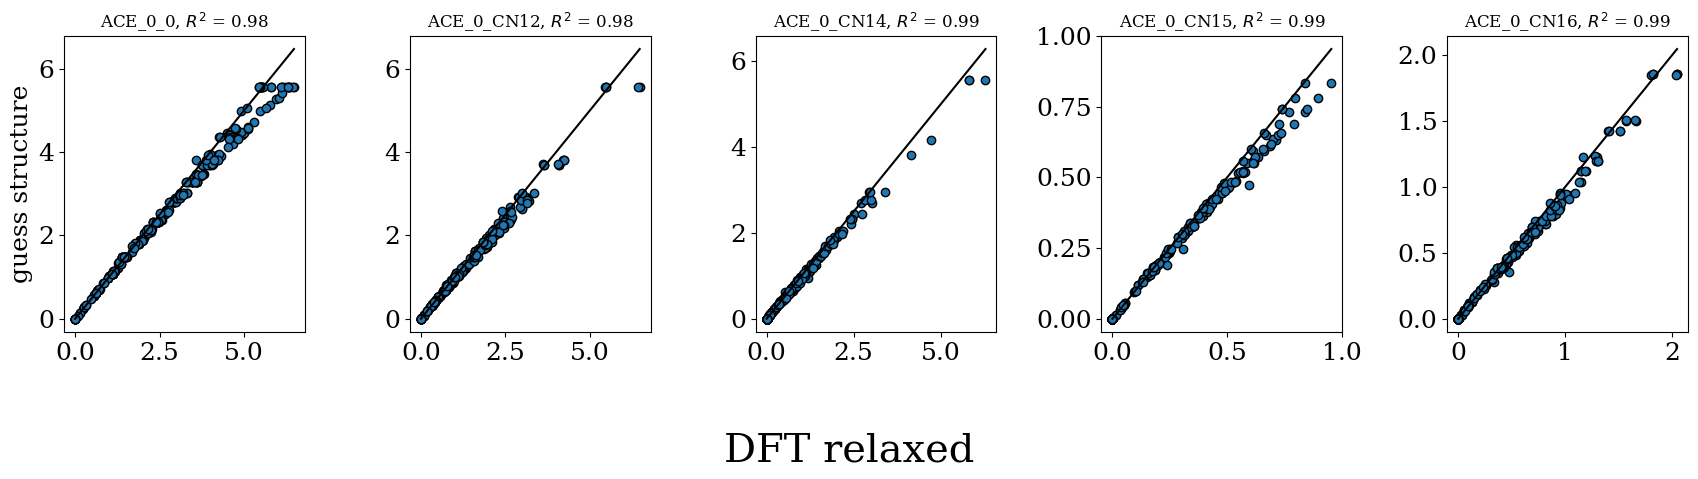

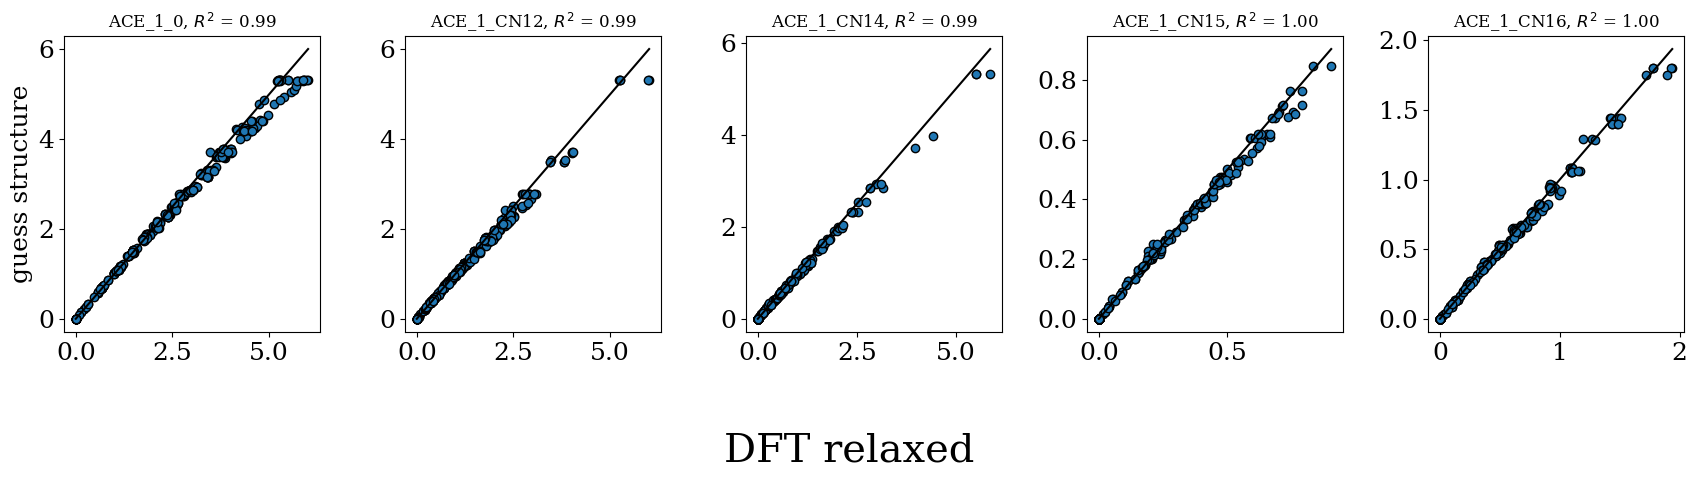

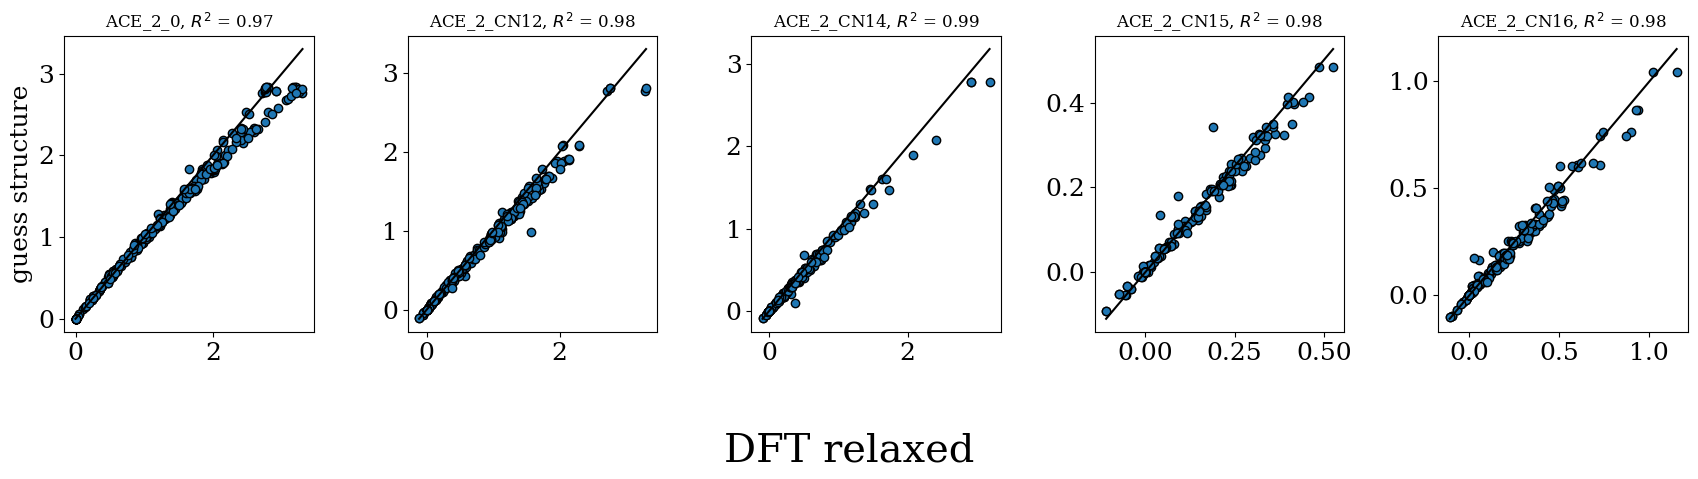

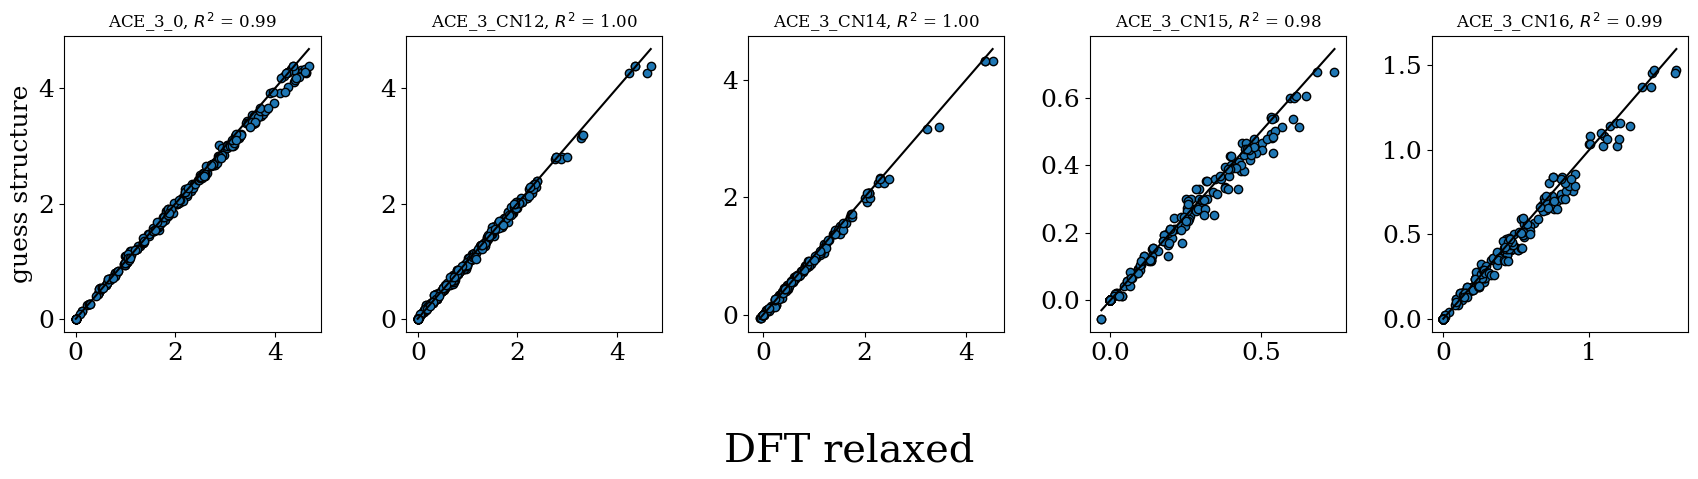

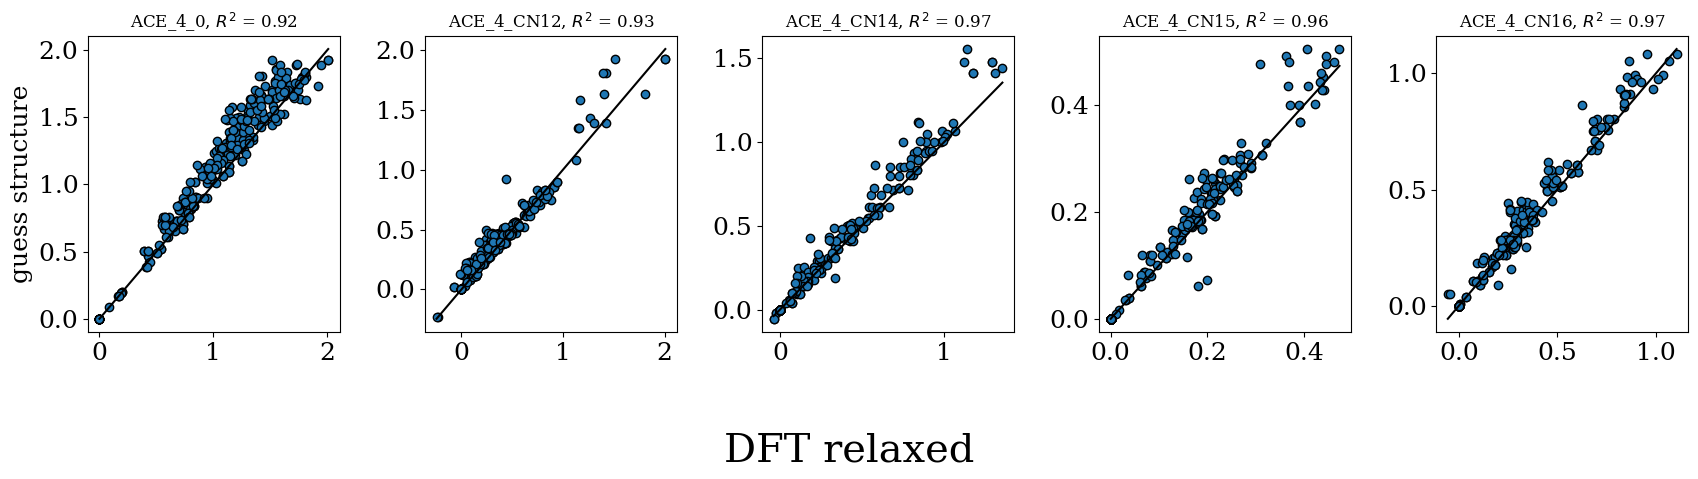

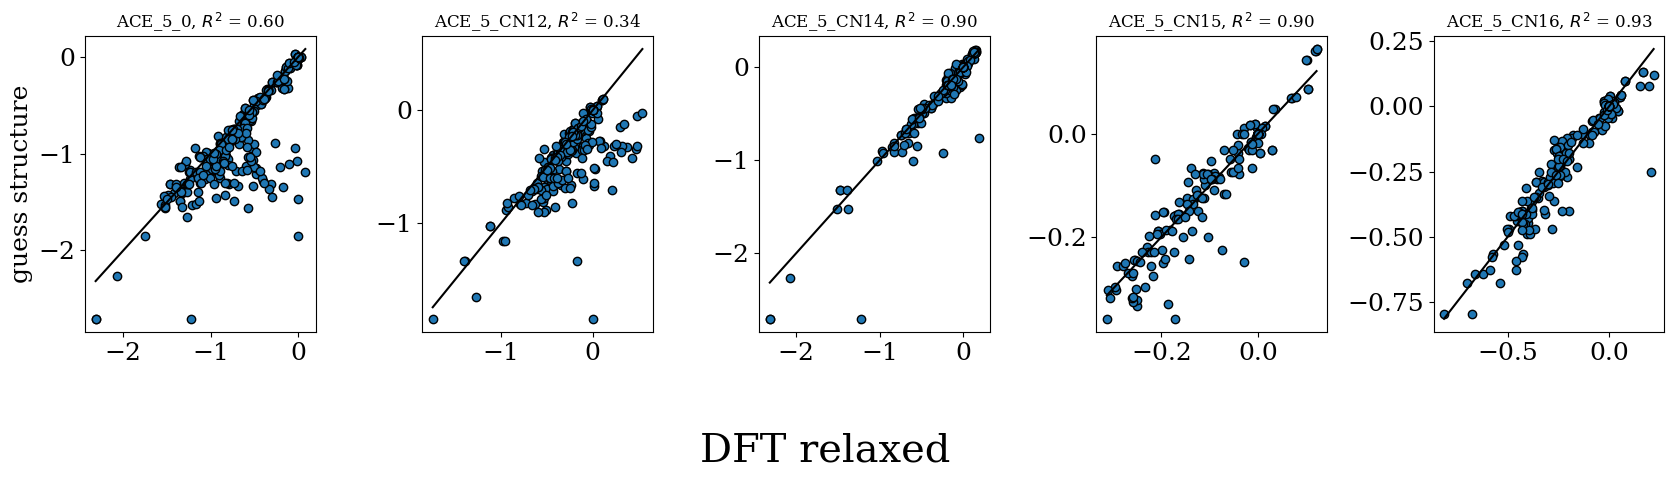

In [57]:
for i in range(6):
    fw, fh = plt.rcParams['figure.figsize']
    fig,axs = plt.subplots(1,5, figsize=(fw*5/2, fh))
    for CN, ax in zip(['0','CN12', 'CN14', 'CN15', 'CN16'], axs):
        feature = f'ace_projections_{i}_{CN}'
        x = CNAV_ACE_RLX[feature]
        y = CNAV_ACE[feature]
    #    reg = np.poly1d(np.polyfit(x, y, 1))
    #    ytilde = reg(x)
        r2 = r2_score(y, x)
        ax.scatter(x, y , ec='k')
        proj_0_range = [CNAV_ACE_RLX[feature].min(), CNAV_ACE_RLX[feature].max()] 
        ax.plot(proj_0_range, proj_0_range, 'k')
        ax.set_title(feature.replace('ace_projections', 'ACE')+f', $R^2$ = {r2:.2f}', fontsize=12)
    axs[0].set_ylabel('guess structure')
    fig.supxlabel('DFT relaxed')
    fig.tight_layout()

In [58]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=24)

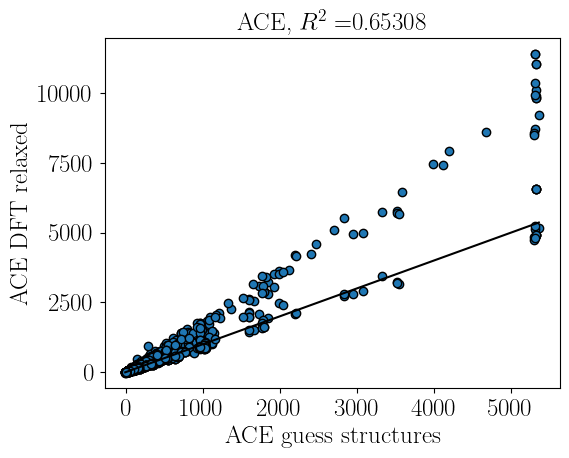

In [59]:
X=    np.ravel(CNAV_ACE)
Y=    np.ravel(CNAV_ACE_RLX)
fig = plt.figure()
ax = fig.add_subplot([0.25, 0.2, 0.65, 0.7])
ax.scatter(X,Y, ec='k')
#plt.yscale('log')
#plt.xscale('log')
therange = [X.min(), X.max()]
r2 = r2_score(X,Y)
plt.ylabel('ACE DFT relaxed')
plt.xlabel('ACE guess structures')
plt.plot(therange,therange, '-k')
plt.title(f'ACE, $R^2 = ${r2:.5f}', fontsize=18)
plt.savefig('Fe-Mo/graphs/Figure_Fe-Mo_ACE_rlx-vs-ini.png', dpi = 300)


# Prepare for prediction

## ACE no zero

In [60]:
components

['Fe', 'Mo']

In [61]:
nozero_acer = MyPyACECalculator(components, multispace_basis_config=AceConfig, exclude_ls=[0])

In [62]:
all_funcspecs = []
for block in nozero_acer.new_bbasis.funcspecs_blocks:
    [all_funcspecs.append(spec) for spec in block.funcspecs]
    

In [63]:
all_funcspecs

[BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[1,1],  ls=[1,1],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[1,1],  ls=[2,2],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[1,1],  ls=[3,3],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[1,2],  ls=[1,1],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[1,2],  ls=[2,2],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[1,2],  ls=[3,3],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[1,3],  ls=[1,1],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[1,3],  ls=[2,2],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[1,3],  ls=[3,3],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[2,2],  ls=[1,1],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[2,2],  ls=[2,2],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=

In [64]:
len(all_funcspecs)

258

In [65]:
NOZEROACEFEATURES = AtomsObjects['atoms'].map(nozero_acer.get_ace_projections)
NOZEROACEFEATURES.name = 'light_ace_projections'

In [66]:
expand_NOZEROACEFEATURES = gf.array_expansions(NOZEROACEFEATURES.to_frame(), ['light_ace_projections'])

In [67]:
CNAV_NOZEROACEFEATURES = gf.featurize_dataframe(expand_NOZEROACEFEATURES, CNList).astype(np.single)

  0%|          | 0/129 [00:00<?, ?it/s]

In [68]:
CNAV_NOZEROACEFEATURES.shape

(292, 774)

In [69]:
CNAV_ACE.shape

(292, 1800)

In [70]:
NOZERO_ACE_file = os.path.join(descriptorslocation, f'{dataset}-NOZERO-ACE-CNAV.csv')

CNAV_NOZEROACEFEATURES.to_csv(NOZERO_ACE_file)

## NOZERO NOONE ACE

In [71]:
nozero_noone_acer = MyPyACECalculator(components, multispace_basis_config=AceConfig, exclude_ls=[0,1])

In [72]:
all_funcspecs_nozeronoone = []
for block in nozero_noone_acer.new_bbasis.funcspecs_blocks:
    [all_funcspecs_nozeronoone.append(spec) for spec in block.funcspecs]
    

In [73]:
nozero_noone_acer.bbasis_configuration

BBasisConfiguration(deltaSplineBins=0.001, funcspecs_blocks=['Fe', 'Mo', 'Fe Mo', 'Mo Fe', ])

In [74]:
NOZERO_NOONE_ACEFEATURES = AtomsObjects['atoms'].map(nozero_noone_acer.get_ace_projections)
NOZERO_NOONE_ACEFEATURES.name = 'light_ace_projections'

In [75]:
expand_NOZERO_NOONE_ACEFEATURES = gf.array_expansions(NOZERO_NOONE_ACEFEATURES.to_frame(), ['light_ace_projections'])

In [76]:
CNAV_NOZERO_NOONE_CEFEATURES = gf.featurize_dataframe(expand_NOZERO_NOONE_ACEFEATURES, CNList).astype(np.single)

  0%|          | 0/62 [00:00<?, ?it/s]

In [77]:
CNAV_NOZERO_NOONE_CEFEATURES.shape

(292, 372)

In [78]:
CNAV_ACE.shape

(292, 1800)

In [79]:
NOZERO_NOONE_ACE_file = os.path.join(descriptorslocation, f'{dataset}-NOZERO_NOONE-ACE-CNAV.csv')

CNAV_NOZERO_NOONE_CEFEATURES.to_csv(NOZERO_NOONE_ACE_file)

## NOZERO NOONE NOTWO ACE

In [80]:
nozero_noone_notwo_acer = MyPyACECalculator(components, multispace_basis_config=AceConfig, exclude_ls=[0,1,2])

In [81]:
all_funcspecs_nozeronoonenotwo = []
for block in nozero_noone_notwo_acer.new_bbasis.funcspecs_blocks:
    [all_funcspecs_nozeronoonenotwo.append(spec) for spec in block.funcspecs]
    

In [82]:
nozero_noone_notwo_acer.bbasis_configuration

BBasisConfiguration(deltaSplineBins=0.001, funcspecs_blocks=['Fe', 'Mo', 'Fe Mo', 'Mo Fe', ])

In [83]:
NOZERO_NOONE_NOTWO_ACEFEATURES = AtomsObjects['atoms'].map(nozero_noone_notwo_acer.get_ace_projections)
NOZERO_NOONE_NOTWO_ACEFEATURES.name = 'light_ace_projections'

In [84]:
expand_NOZERO_NOONE_NOTWO_ACEFEATURES = gf.array_expansions(NOZERO_NOONE_NOTWO_ACEFEATURES.to_frame(), ['light_ace_projections'])

In [85]:
CNAV_NOZERO_NOONE_NOTWO_CEFEATURES = gf.featurize_dataframe(expand_NOZERO_NOONE_NOTWO_ACEFEATURES, CNList).astype(np.single)

  0%|          | 0/21 [00:00<?, ?it/s]

In [86]:
CNAV_NOZERO_NOONE_NOTWO_CEFEATURES.shape

(292, 126)

In [87]:
CNAV_ACE.shape

(292, 1800)

In [88]:
NOZERO_NOONE_NOTWO_ACE_file = os.path.join(descriptorslocation, f'{dataset}-NOZERO_NOONE_NOTWO-ACE-CNAV.csv')

CNAV_NOZERO_NOONE_CEFEATURES.to_csv(NOZERO_NOONE_NOTWO_ACE_file)

## NOTHREE ACE

In [89]:
nothree_acer = MyPyACECalculator(components, multispace_basis_config=AceConfig, exclude_ls=[3])

In [90]:
all_funcspecs_nothree = []
for block in nothree_acer.new_bbasis.funcspecs_blocks:
    [all_funcspecs_nothree.append(spec) for spec in block.funcspecs]
    

In [91]:
NOTHREE_ACEFEATURES = AtomsObjects['atoms'].map(nothree_acer.get_ace_projections)
NOTHREE_ACEFEATURES.name = 'light_ace_projections'

In [92]:
expand_NOTHREE_ACEFEATURES = gf.array_expansions(NOTHREE_ACEFEATURES.to_frame(), ['light_ace_projections'])

In [93]:
CNAV_NOTHREE_ACEFEATURES = gf.featurize_dataframe(expand_NOTHREE_ACEFEATURES, CNList).astype(np.single)

  0%|          | 0/279 [00:00<?, ?it/s]

In [94]:
CNAV_NOTHREE_ACEFEATURES.shape

(292, 1674)

In [95]:
NOTHREE_ACE_file = os.path.join(descriptorslocation, f'{dataset}-NOTHREE-ACE-CNAV.csv')

CNAV_NOTHREE_ACEFEATURES.to_csv(NOTHREE_ACE_file)

## NOTHREE NOTWO ACE

In [96]:
nothree_notwo_acer = MyPyACECalculator(components, multispace_basis_config=AceConfig, exclude_ls=[2,3])

In [97]:
all_funcspecs_nothree_notwo = []
for block in nothree_notwo_acer.new_bbasis.funcspecs_blocks:
    [all_funcspecs_nothree_notwo.append(spec) for spec in block.funcspecs]

In [98]:
NOTHREE_NOTWO_ACEFEATURES = AtomsObjects['atoms'].map(nothree_notwo_acer.get_ace_projections)
NOTHREE_NOTWO_ACEFEATURES.name = 'light_ace_projections'

In [99]:
expand_NOTHREE_NOTWO_ACEFEATURES = gf.array_expansions(NOTHREE_NOTWO_ACEFEATURES.to_frame(), ['light_ace_projections'])

In [100]:
CNAV_NOTHREE_NOTWO_ACEFEATURES = gf.featurize_dataframe(expand_NOTHREE_NOTWO_ACEFEATURES, CNList).astype(np.single)

  0%|          | 0/158 [00:00<?, ?it/s]

In [101]:
NOTHREE_NOTWO_ACE_file = os.path.join(descriptorslocation, f'{dataset}-NOTHREE_NOTWO-ACE-CNAV.csv')

CNAV_NOTHREE_NOTWO_ACEFEATURES.to_csv(NOTHREE_NOTWO_ACE_file)

## NOTHREE NOTWO NOONE ACE

In [102]:
nothree_notwo_noone_acer = MyPyACECalculator(components, multispace_basis_config=AceConfig, exclude_ls=[1,2,3])

In [103]:
all_funcspecs_nothree_notwo_noone = []
for block in nothree_notwo_noone_acer.new_bbasis.funcspecs_blocks:
    [all_funcspecs_nothree_notwo_noone.append(spec) for spec in block.funcspecs]

In [104]:
NOTHREE_NOTWO_NOONE_ACEFEATURES = AtomsObjects['atoms'].map(nothree_notwo_noone_acer.get_ace_projections)
NOTHREE_NOTWO_NOONE_ACEFEATURES.name = 'light_ace_projections'

In [105]:
expand_NOTHREE_NOTWO_NOONE_ACEFEATURES = gf.array_expansions(NOTHREE_NOTWO_NOONE_ACEFEATURES.to_frame(), ['light_ace_projections'])

In [106]:
CNAV_NOTHREE_NOTWO_NOONE_ACEFEATURES = gf.featurize_dataframe(expand_NOTHREE_NOTWO_NOONE_ACEFEATURES, CNList).astype(np.single)

  0%|          | 0/82 [00:00<?, ?it/s]

In [107]:
CNAV_NOTHREE_NOTWO_NOONE_ACEFEATURES.shape

(292, 492)

In [108]:
CNAV_ACE.shape

(292, 1800)

In [109]:
NOTHREE_NOTWO_NOONE_ACE_file = os.path.join(descriptorslocation, f'{dataset}-NOTHREE_NOTWO_NOONE-ACE-CNAV.csv')

CNAV_NOTHREE_NOTWO_NOONE_ACEFEATURES.to_csv(NOTHREE_NOTWO_NOONE_ACE_file)
(NOTHREE_NOTWO_NOONE_ACE_file)

'Fe-Mo/Descriptors/Fe-Mo-NOTHREE_NOTWO_NOONE-ACE-CNAV.csv'

## Canonical 

In [110]:
CanonicalAceConfig = copy.copy(AceConfig)

In [111]:
CanonicalAceConfig['elements'] = ['W']

In [112]:
CanonicalACEer = MyPyACECalculator(components = CanonicalAceConfig['elements'], multispace_basis_config=CanonicalAceConfig)

In [113]:
canonicalatomsobjects = AtomsObjects['atoms'].map(reset_symbols)

In [114]:
canonicalacedescriptors = canonicalatomsobjects.map(CanonicalACEer.get_ace_projections)
canonicalacedescriptors.name = 'canonical_ace_projections'

In [115]:
expand_canonical_ace = gf.array_expansions(canonicalacedescriptors.to_frame(),['canonical_ace_projections']) 

In [116]:
CNAV_CANONICAL_ACE = gf.featurize_dataframe(expand_canonical_ace, CNList).astype(np.single)

  0%|          | 0/69 [00:00<?, ?it/s]

In [117]:
CNAV_CANONICAL_ACE

,canonical_ace_projections_0_0,canonical_ace_projections_0_CN12,canonical_ace_projections_0_CN13,canonical_ace_projections_0_CN14,canonical_ace_projections_0_CN15,canonical_ace_projections_0_CN16,canonical_ace_projections_1_0,canonical_ace_projections_1_CN12,canonical_ace_projections_1_CN13,canonical_ace_projections_1_CN14,...,canonical_ace_projections_67_CN13,canonical_ace_projections_67_CN14,canonical_ace_projections_67_CN15,canonical_ace_projections_67_CN16,canonical_ace_projections_68_0,canonical_ace_projections_68_CN12,canonical_ace_projections_68_CN13,canonical_ace_projections_68_CN14,canonical_ace_projections_68_CN15,canonical_ace_projections_68_CN16
Fe_pv4Mo_sv20.C36-ABBBB.FM,4.197044,2.794807,0.0,0.000000,0.000000,1.402237,4.250290,2.773875,0.0,0.000000,...,0.0,0.000000e+00,0.000000e+00,4.741674e-08,1302.364380,863.234863,0.0,0.000000,0.000000,439.129608
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,4.351257,2.217324,0.0,0.983367,0.495760,0.654808,4.377278,2.178550,0.0,1.003156,...,0.0,4.266128e-06,2.691233e-06,4.437061e-07,1560.404541,796.203857,0.0,349.957031,182.328415,231.915253
Fe_pv2Mo_sv11.mu-BBABB.FM,4.187475,2.270445,0.0,0.630194,0.619778,0.667059,4.226473,2.203496,0.0,0.663000,...,0.0,7.721195e-04,4.582254e-13,1.922932e-08,1294.956787,718.523560,0.0,177.428421,163.242355,235.762436
Fe_pv8Mo_sv22.sigma-BBBAB.NM,4.328737,1.442123,0.0,2.307938,0.578676,0.000000,4.371367,1.431755,0.0,2.341648,...,0.0,4.450284e-08,2.070303e-09,0.000000e+00,1519.899658,505.241943,0.0,809.341736,205.315964,0.000000
Fe_pv2Mo_sv11.mu-BBBBA.NM,4.187475,2.270445,0.0,0.630194,0.619778,0.667059,4.226473,2.203496,0.0,0.663000,...,0.0,7.721195e-04,4.582254e-13,1.922932e-08,1294.956787,718.523560,0.0,177.428421,163.242355,235.762436
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Mo_sv1.bcc.NM,4.000309,0.000000,0.0,4.000309,0.000000,0.000000,4.134325,0.000000,0.0,4.134325,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1024.395142,0.000000,0.0,1024.395142,0.000000,0.000000
Mo_sv8.A15.NM,3.996108,0.999231,0.0,2.996877,0.000000,0.000000,4.114518,1.029678,0.0,3.084840,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1019.029419,255.017288,0.0,764.012085,0.000000,0.000000
Mo_sv1.fcc.NM,3.993777,3.993777,0.0,0.000000,0.000000,0.000000,4.105636,4.105636,0.0,0.000000,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1016.059265,1016.059265,0.0,0.000000,0.000000,0.000000
Mo_sv6.C15.NM,3.996061,2.665535,0.0,0.000000,0.000000,1.330526,4.096406,2.761814,0.0,0.000000,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1018.994019,681.238892,0.0,0.000000,0.000000,337.755096


In [118]:
canonical_ACE_file = os.path.join(descriptorslocation, f'{dataset}-canonical-ACE-CNAV.csv')

In [119]:
CNAV_CANONICAL_ACE.to_csv(canonical_ACE_file)